In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#Load Dataset
df = pd.read_csv("sales_data.csv")
print("First 5 rows:")
print(df.head())

First 5 rows:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680


In [3]:
#Descriptive Statistics
sales = df["Total_Sales"]
mean = sales.mean()
median = sales.median()
mode = sales.mode()[0]
std = sales.std()

print("\nDescriptive Statistics:")
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)
print("Standard Deviation:", std)


Descriptive Statistics:
Mean: 123650.48
Median: 97955.5
Mode: 6540
Standard Deviation: 100161.08527499212


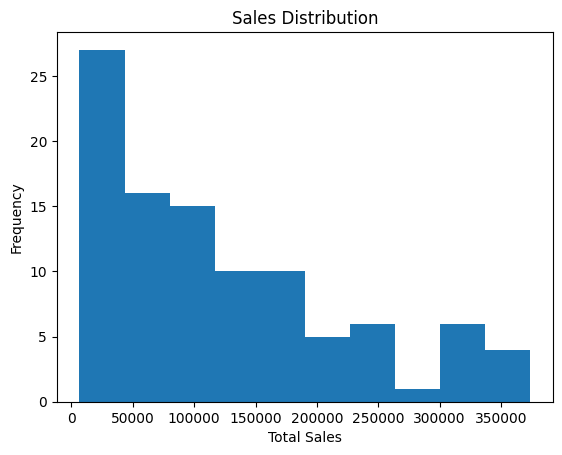


Normality Test p-value: 1.259076720571478e-06


In [4]:
#Distribution Analysis
plt.figure()
plt.hist(sales)
plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

# Normality Test
stat, p = stats.shapiro(sales)
print("\nNormality Test p-value:", p)


Correlation Matrix:
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


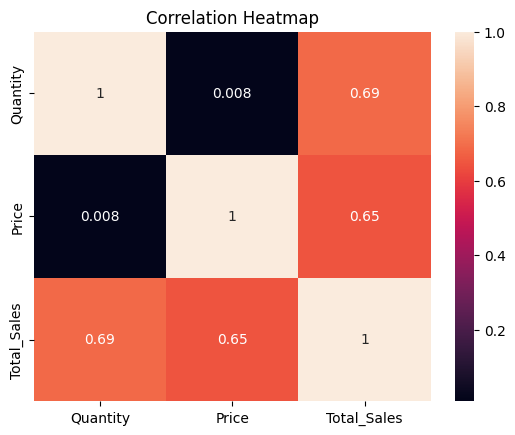

In [5]:
#Correlation Analysis
correlation_matrix = df[["Quantity", "Price", "Total_Sales"]].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure()
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
#Hypothesis Testing
# 1. One-sample t-test
t_stat, p_val = stats.ttest_1samp(sales, 200000)
print("\nOne-sample t-test p-value:", p_val)

# 2. Two-sample t-test (Region comparison)
regions = df["Region"].unique()

group1 = df[df["Region"] == regions[0]]["Total_Sales"]
group2 = df[df["Region"] == regions[1]]["Total_Sales"]

t2_stat, p_val2 = stats.ttest_ind(group1, group2)
print("Two-sample t-test p-value:", p_val2)

# 3. ANOVA
groups = [df[df["Region"] == r]["Total_Sales"] for r in regions]
f_stat, p_val3 = stats.f_oneway(*groups)

print("ANOVA p-value:", p_val3)


One-sample t-test p-value: 1.529271713575926e-11
Two-sample t-test p-value: 0.7226811638407535
ANOVA p-value: 0.09723678084979993


In [7]:
#Confidence Interval
mean = sales.mean()
sem = stats.sem(sales)
ci = stats.t.interval(0.95, len(sales)-1, loc=mean, scale=sem)
print("\n95% Confidence Interval:", ci)


95% Confidence Interval: (103776.34767158539, 143524.6123284146)



Regression Results:
Slope: 4.650014143657133
Intercept: 3640.5434732834547
R-squared: 0.41748520826938135
p-value: 3.8821632176368017e-13


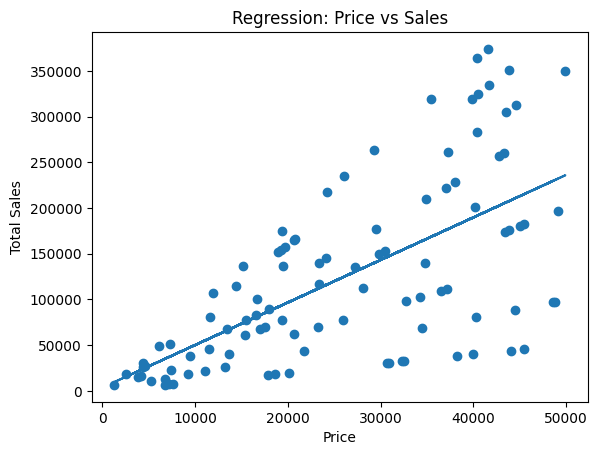

In [8]:
#Regression Analysis
slope, intercept, r_value, p_value, std_err = stats.linregress(df["Price"], sales)

print("\nRegression Results:")
print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_value**2)
print("p-value:", p_value)

# Regression Line Plot
plt.figure()
plt.scatter(df["Price"], sales)
plt.plot(df["Price"], intercept + slope * df["Price"])
plt.title("Regression: Price vs Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")
plt.show()

In [9]:
#Final Summary Output
print("\n===== FINAL REPORT =====")
print(f"Average Sales: ${round(mean,2)} ± {round((ci[1]-ci[0])/2,2)} (95% CI)")
print(f"Correlation (Price vs Sales): {round(correlation_matrix.loc['Price','Total_Sales'],2)}")
print(f"Regression R²: {round(r_value**2,2)}")
print(f"Hypothesis Test p-value: {round(p_value,4)}")


===== FINAL REPORT =====
Average Sales: $123650.48 ± 19874.13 (95% CI)
Correlation (Price vs Sales): 0.65
Regression R²: 0.42
Hypothesis Test p-value: 0.0
